# Test and Evaluate Crop Recommendation Model

This notebook loads the trained Keras neural network model, preprocessing states (scaler and label encoder), performs evaluation on a test set, and provides a utility for custom crop recommendations.

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


### 1. Load Preprocessing Artifacts and Keras Model

In [2]:
# Load scaler
with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load label encoder
with open('models/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# Load Keras model
model = tf.keras.models.load_model('models/crop_recommendation_model.keras')
print("Loaded model and preprocessors successfully.")
model.summary()

Loaded model and preprocessors successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         1,188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,438 (154.06 KB)

 Trainable params: 12,996 (50.77 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 25,994 (101.54 KB)

### 2. Load Dataset and Recreate Test Partition

In [3]:
df = pd.read_csv('data/crop_recommendation.csv')
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']

# Transform using loaded encoder & scaler
y_encoded = label_encoder.transform(y)
X_scaled = scaler.transform(X)

# Split using same random state to isolate the exact test/validation set
_, X_test, _, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Test Set Shape:", X_test.shape)

Test Set Shape: (3600, 7)


### 3. Predict and Evaluate Model Performance
We calculate the predictions, accuracy score, and show a classification report with precision, recall, and F1-score for all 36 crops.

In [4]:
# Run predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Deep Learning Model Test Accuracy: {acc:.2%}\n")

# Classification report
crop_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=crop_names))

  1/113 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step

 26/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

 56/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 81/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

109/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Deep Learning Model Test Accuracy: 96.39%

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00       100
       bajra       0.99      1.00      1.00       100
      banana       1.00      1.00      1.00       100
      barley       1.00      1.00      1.00       100
   blackgram       0.98      1.00      0.99       100
    chickpea       1.00      1.00      1.00       100
     coconut       1.00      1.00      1.00       100
      coffee       1.00      1.00      1.00       100
      cotton       1.00      0.97      0.98       100
      grapes       1.00      1.00      1.00       100
   groundnut       0.94      0.91      0.92       100
       jowar       0.98      0.98      0.98       100
        jute       0.88      0.99      0.93       100
 kidneybeans       0.89      0.95      0.92       100
      lentil       0.99      0.99      0.99       100
       maize       0.89      0.87      0.88       100
       mango       0.98      0.98     

### 4. Plot Confusion Matrix
Visualize the performance across all crops using a confusion matrix heatmap.

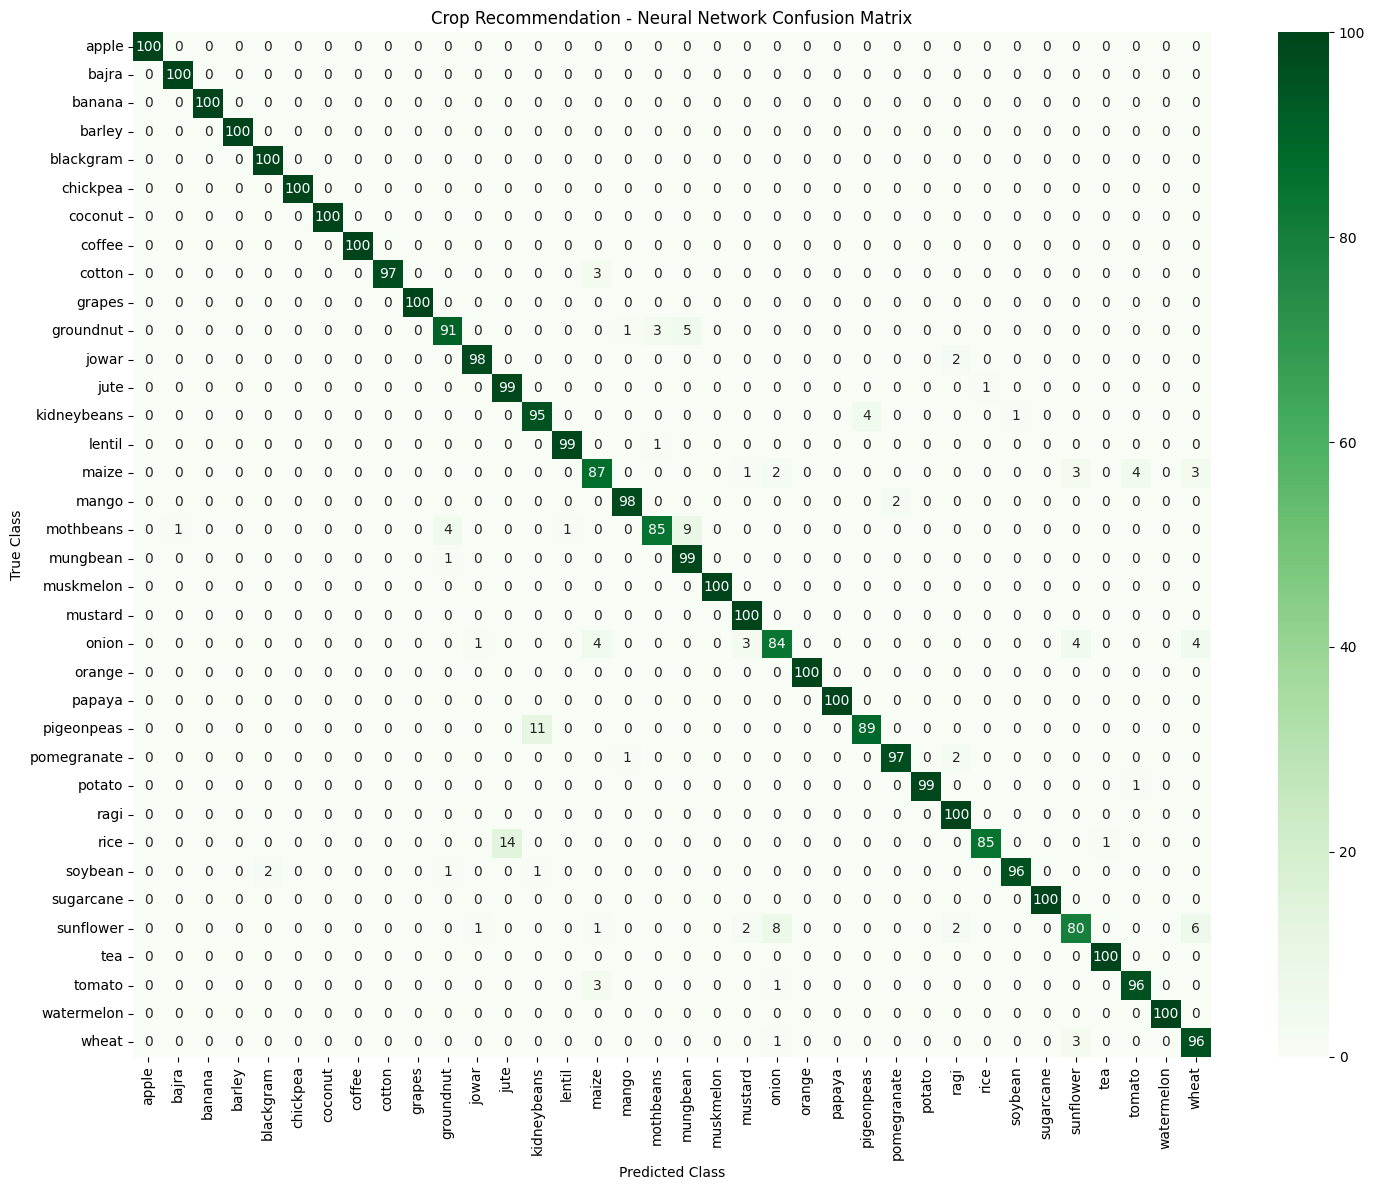

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, xticklabels=crop_names, yticklabels=crop_names, annot=True, fmt='d', cmap='Greens')
plt.title('Crop Recommendation - Neural Network Confusion Matrix')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

### 5. Custom Crop Prediction Function
Here we define a helper function to recommend crops given custom soil features and climate values.

In [6]:
def recommend_crop(N, P, K, temp, humidity, ph, rainfall, top_k=3):
    # Standardize input values
    input_data = np.array([[N, P, K, temp, humidity, ph, rainfall]])
    input_scaled = scaler.transform(input_data)
    
    # Predict probabilities
    pred_probs = model.predict(input_scaled)[0]
    
    # Get top-k indices
    top_indices = np.argsort(pred_probs)[::-1][:top_k]
    
    print(f"=== Top {top_k} Recommended Crops ===")
    for i, idx in enumerate(top_indices):
        crop = label_encoder.inverse_transform([idx])[0]
        prob = pred_probs[idx]
        print(f"{i+1}. {crop.capitalize()} (Confidence: {prob:.2%})")

# Example test prediction:
# N=80, P=40, K=40, temp=25C, humidity=80%, ph=6.5, rainfall=200mm
recommend_crop(N=80, P=40, K=40, temp=25.0, humidity=80.0, ph=6.5, rainfall=200.0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


=== Top 3 Recommended Crops ===
1. Jute (Confidence: 96.10%)
2. Rice (Confidence: 3.90%)
3. Papaya (Confidence: 0.00%)


C:\Users\lenovo\Downloads\AI-Powered-Crop-Recommendation-main\AI-Powered-Crop-Recommendation-main\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
